# viz_osm_newbie.ipynb
# visualises newbie changeset locations on map
# input: changeset data for AOI from OSMCha (https://osmcha.org/)
# output: Plot center coordinates of changesets on map


In [106]:
# read data
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta

plt.style.use("seaborn-v0_8")


In [107]:

#1 read changesets data
osmcha_changesets=pd.read_pickle("data/osmcha_changesets.pkl")
osmcha_changesets.head()


,id,type,geometry_type,geometry_coordinates,properties_check_user,properties_reasons,properties_tags,properties_features,properties_user,properties_uid,...,properties_tag_changes_type,properties_tag_changes_name:te,properties_tag_changes_short_name:te,properties_tag_changes_loc_name:name:loc,properties_tag_changes_informal,properties_tag_changes_healthcare,properties_tag_changes_healthcare:speciality,tags_map,first_month,discussion_status
0,176768410,Feature,Polygon,"[[[80.1112946, 16.166866], [80.1112946, 16.166...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 86, ...",[],[],Pavan Komirisetty,23668422,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},2026-01,no_comments
1,176891017,Feature,Polygon,"[[[80.8289802, 16.0351363], [80.8402645, 16.03...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]","[{'id': 10, 'name': 'Unresolved'}]",[],Mohana Dokku,23677212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{10: 'Unresolved'},2026-01,has_comments
2,176892861,Feature,Polygon,"[[[80.1910467, 15.8971858], [80.200224, 15.897...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}, {'id': 517,...","[{'id': 6, 'name': 'Severity: Low'}]",[],Amarnath07,23677287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{6: 'Severity: Low'},2026-01,has_comments
3,176894070,Feature,Polygon,"[[[80.0167603, 15.7050239], [80.0815638, 15.70...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],KrisVar,23677295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},2026-01,has_comments
4,176894166,Feature,Polygon,"[[[79.5521225, 13.6016232], [79.5791831, 13.60...",arjunaraoc,"[{'id': 40, 'name': 'New mapper'}]",[],[],Balaraju Bollini,23677297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},2026-01,has_comments


In [108]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def changeset_centroid(a,b,c,d):
    if (a[0]==b[0] and a[1]==b[1]):
        return(a[0],a[1])
    else:
        return((a[0]+d[0])/2,(a[1]+d[1])/2)

def changeset_point(a,b,c,d):
    if (a[0]==b[0] and a[1]==b[1]):
        return(True)
    else:
        return(False)

# 1. Add geometry directly to the original DataFrame
osmcha_changesets["changeset_centroid"] = osmcha_changesets["geometry_coordinates"].apply(
    lambda x: Point(changeset_centroid(x[0][0], x[0][1], x[0][2], x[0][3]))
)
# 1. Add geometry directly to the original DataFrame
osmcha_changesets["changeset_point"] = osmcha_changesets["geometry_coordinates"].apply(
    lambda x: changeset_point(x[0][0], x[0][1], x[0][2], x[0][3])
)

# 2. Convert to GeoDataFrame safely
osmcha_gdf = gpd.GeoDataFrame(osmcha_changesets, geometry="changeset_centroid", crs="EPSG:4326")


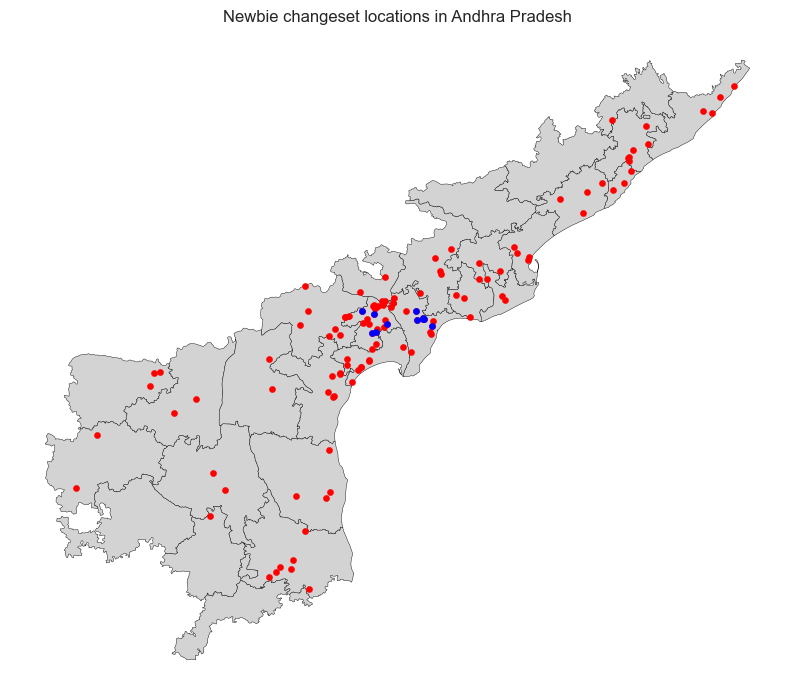

In [ ]:
# Load your local GeoJSON file
ap_districts = gpd.read_file("data/ap districts 2026 simplified.geojson")

# 2. Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map first
ap_districts.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the points on top

osmcha_gdf.plot(ax=ax, color='red', markersize=20, marker='o')
#hotosm_gdf=osmcha_gdf[osmcha_gdf['properties_comment'].str.contains('#hotosm-project-17520')]
#hotosm_gdf.plot(ax=ax, color='blue', markersize=20, marker='o')
# Customize and show
plt.title("Newbie changeset locations in Andhra Pradesh")
plt.axis('off')
plt.show()


In [ ]:
ap_districts.head()

In [ ]:

# 2. Print the entire first row as a Series (Column Name -> Value)



for col, val in osmcha_changesets.iloc[0].items():
    print(f"{col}: {val}")


In [ ]:
import statistics
print(statistics.median(osmcha_changesets["properties_create"]))
print(statistics.median(osmcha_changesets["properties_modify"]))
print(statistics.median(osmcha_changesets["properties_delete"]))

In [ ]:
osmcha_changesets["properties_comment"]

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS, WordCloud

text = osmcha_changesets['properties_comment'].astype(str).str.cat(sep='\n')

# 1. Clean punctuation and lowercase the text
clean_text = re.sub(r"[^\w\s]", "", text.lower())
all_words = clean_text.split()

# 2. Filter out stopwords using a list comprehension
# (STOPWORDS is a fast-lookup set from the wordcloud library)
filtered_words = [word for word in all_words if word not in STOPWORDS]

# 3. Get the top 10 most common filtered words
top_10_counts = dict(Counter(filtered_words).most_common(10))
print("Accurate Counts:", top_10_counts)

# 4. Generate and display the WordCloud
wc = WordCloud().generate_from_frequencies(top_10_counts)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:

# Convert to DataFrame
df = pd.DataFrame(top_10_counts.items(), columns=['Word', 'Count'])
df.to_csv("data/top_10_words.csv", index=False)

In [ ]:
# nummber of changesets that are points (i.e., where the coordinates are the same)
osmcha_changesets["changeset_point"].sum()

In [ ]:
# map the changesets centre to district
# 
# 2. Perform the spatial join
# By passing how='left', you ensure all points are kept, even if they don't fall in any polygon
joined_gdf = gpd.sjoin(osmcha_gdf, ap_districts, how="left", predicate="within")

# 3. Extract the original polygon index
# When joining, the polygon's index is stored in the column 'index_right'
joined_gdf['polygon_index'] = joined_gdf['index_right'].astype('Int64')  # Use Int64 to allow for NaN values
joined_gdf.head()


In [ ]:
# Create csv file for number of changesets per district
joined_gdf['name'].value_counts().to_csv("data/changesets_per_district.csv", index=True, header=True)

In [ ]:
# list of districts that have no changesets
missing_indices = ap_districts.index[~ap_districts.index.isin(joined_gdf['polygon_index'].dropna())]
missing_gpd=ap_districts.iloc[missing_indices]
missing_gpd=missing_gpd.dropna(subset=['admin_level'])
missing_gpd['name']